# rnns-jax quickstart

The library gives you models and a `fit` function. You prepare the data yourself:

1. Build input windows `X` of shape `(N, window, in_ftrs)` and targets `y` of shape `(N, out_ftrs)` as NumPy arrays.
2. Train with `fit`.
3. Predict, save, load and swap models.

Install: `uv add git+https://github.com/mkeriy/rnns-jax.git` or `pip install git+https://github.com/mkeriy/rnns-jax.git`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from flax import nnx
from numpy.lib.stride_tricks import sliding_window_view

from rnns_jax import GRU, LSTM, TrainConfig, fit, load_model, save_model

/Users/damimilko/quant/competitions/rnns-jax/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

Synthetic data: 30 independent sequences of 400 steps, each with two noisy sine-like features and its own frequency.
`data` has shape `(sequences, time steps, features)`.

In [2]:
rng = np.random.default_rng(0)
t = np.arange(400) * 0.1
freqs = rng.uniform(0.5, 1.5, size=(30, 1))
data = np.stack(
    [np.sin(freqs * t), np.cos(0.5 * freqs * t)], axis=-1
) + 0.05 * rng.normal(size=(30, 400, 2))
data = data.astype(np.float32)
data.shape

(30, 400, 2)

## 2. Windows

Each sample is 50 consecutive steps of one sequence, and its target is the step right after.
`make_windows` below does this for one sequence:

- `sliding_window_view(seq[:-1], window, axis=0)` gives every 50-step slice as `(N, features, window)`; `.transpose(0, 2, 1)` makes it `(N, window, features)`. `seq[:-1]` leaves room for the last target.
- `seq[window:]` is the step after each window.

Split **by sequence** first (24 for training, 6 for validation) so no validation steps leak into training, then window each sequence and stack them.

In [3]:
def make_windows(seq, window):
    X = sliding_window_view(seq[:-1], window, axis=0).transpose(0, 2, 1)
    y = seq[window:]
    return X, y


def windows_for(sequences, window=50):
    pairs = [make_windows(seq, window) for seq in sequences]
    return np.concatenate([X for X, _ in pairs]), np.concatenate([y for _, y in pairs])


X_train, y_train = windows_for(data[:24])
X_val, y_val = windows_for(data[24:])
print("train", X_train.shape, y_train.shape, "| val", X_val.shape, y_val.shape)

train (8400, 50, 2) (8400, 2) | val (2100, 50, 2) (2100, 2)


## 3. Model

`in_ftrs` = number of input features, `out_ftrs` = number of target columns.
`fit` stops with a clear error if they don't match the data.

In [4]:
model = GRU(rngs=nnx.Rngs(0), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1)

## 4. Train

`TrainConfig` holds the optimizer, learning rate (or a scheduler), batch size and epochs. Validation runs at the end of each epoch.

- `ckpt_dir`: after each validation that improves `monitor` (default `val_loss`), the weights are saved there.
- `early_stopping_patience=3`: stop after 3 validations in a row without improvement.
- `fit` returns the **best** weights, not the last ones.
- `history` is a dict of metric lists. Set `logger="tensorboard"` or `logger="wandb"` (with `logger_params`) to also send the metrics there; that needs `pip install "rnns-jax[tensorboard]"` or `"rnns-jax[wandb]"`.

In [5]:
config = TrainConfig(
    epochs=30, batch_size=64, lr=3e-3,
    ckpt_dir="checkpoints/gru_best", early_stopping_patience=3,
)
model, history = fit(model, X_train, y_train, X_val, y_val, config)

epoch 13/30: 100%|██████████| 131/131 [00:00<00:00, 273.50it/s, loss=0.00346]


early stopping at step 1703: best val_loss=0.003487 at step 1310


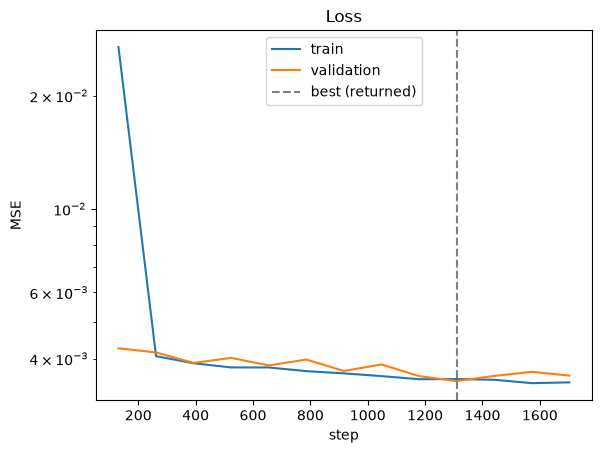

In [6]:
plt.plot(history["train_step"], history["train_loss"], label="train")
plt.plot(history["val_step"], history["val_loss"], label="validation")
plt.axvline(history["best_step"][-1], color="gray", linestyle="--", label="best (returned)")
plt.xlabel("step"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend(); plt.title("Loss")
plt.show()

## 5. Predict

`model(X)` returns `(predictions, state)`. Here: one-step-ahead predictions over a whole validation sequence.

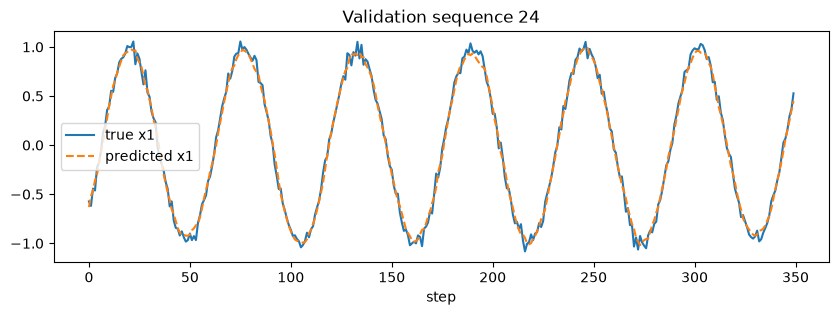

In [7]:
X_seq, y_seq = make_windows(data[24], window=50)
preds, _ = model(X_seq)

plt.figure(figsize=(10, 3))
plt.plot(y_seq[:, 0], label="true x1")
plt.plot(np.asarray(preds)[:, 0], "--", label="predicted x1")
plt.xlabel("step"); plt.legend(); plt.title("Validation sequence 24")
plt.show()

## 6. Save and load

`save_model` writes the weights to a folder. To load, build a model with the **same arguments** and pass it to `load_model`.

In [8]:
save_model(model, "checkpoints/gru")

restored = load_model(
    GRU(rngs=nnx.Rngs(1), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1),
    "checkpoints/gru",
)
restored_preds, _ = restored(X_seq)
print("max difference after reload:", float(np.abs(np.asarray(restored_preds) - np.asarray(preds)).max()))

max difference after reload: 0.0


## 7. Swap the model

All models share the same interface, so trying another architecture is a one-line change.

In [9]:
lstm = LSTM(rngs=nnx.Rngs(0), in_ftrs=2, hidden_ftrs=64, out_ftrs=2, num_layers=1)
lstm_config = TrainConfig(epochs=30, batch_size=64, lr=3e-3, early_stopping_patience=3)
lstm, lstm_history = fit(lstm, X_train, y_train, X_val, y_val, lstm_config)
print(f"best val loss  GRU: {history['best_val_loss'][-1]:.4f}  LSTM: {lstm_history['best_val_loss'][-1]:.4f}")

epoch 13/30: 100%|██████████| 131/131 [00:00<00:00, 210.93it/s, loss=0.00344]

early stopping at step 1703: best val_loss=0.003502 at step 1310
best val loss  GRU: 0.0035  LSTM: 0.0035
